C:\Users\CHIRU\AppData\Local\Temp\ipykernel_7068\1384336002.py:4: DtypeWarning: Columns (3,22,23,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("health_fitness.csv")


Index(['participant_id', 'date', 'age', 'gender', 'height_cm', 'weight_kg',
       'activity_type', 'duration_minutes', 'intensity_type',
       'calories_burned', 'avg_heart_rate', 'hours_sleep', 'sleep_type',
       'stress_level', 'stress_type', 'daily_steps', 'steps_type',
       'hydration_level', 'bmi', 'resting_heart_rate',
       'blood_pressure_systolic', 'blood_pressure_diastolic',
       'health_condition', 'smoking_status', 'fitness_level',
       'fitness_cateogry', 'unnamed: 26', 'unnamed: 27', 'unnamed: 28'],
      dtype='object')
(687700, 29)
(687699, 29)
risk_category
Medium Risk    601485
Low Risk        86214
Name: count, dtype: int64


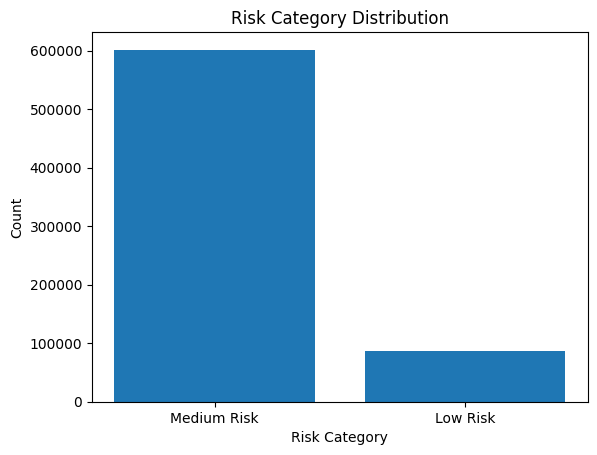

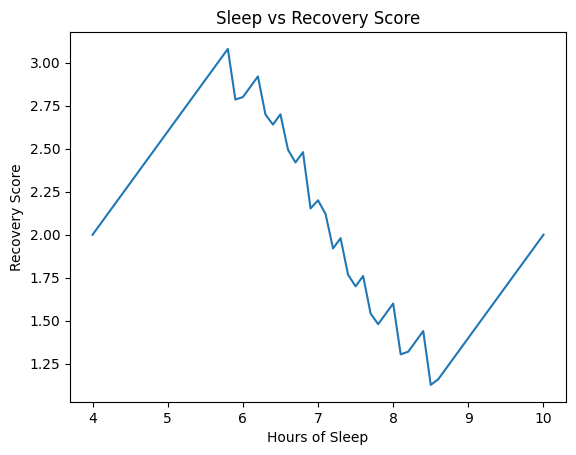

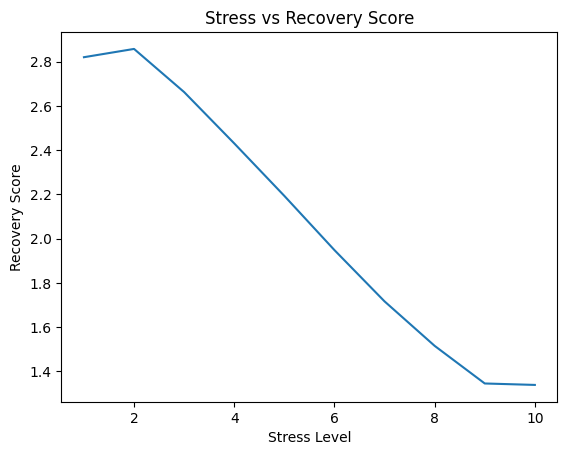

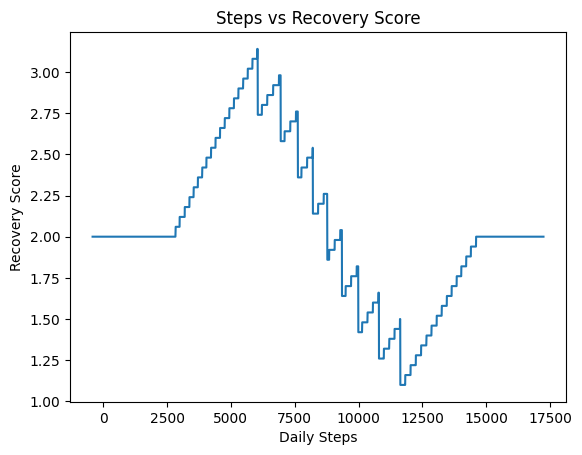

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("health_fitness.csv")

df.columns = df.columns.str.lower().str.strip()

print(df.columns)
print(df.shape)

df = df.dropna(subset=['daily_steps', 'hours_sleep', 'stress_level'])

print(df.shape)

df['wellness_score'] = (
    (df['daily_steps'] / 10000) * 0.25 +   
    (df['hours_sleep'] / 8) * 0.25 +       
    ((10 - df['stress_level']) / 10) * 0.5 
) * 100

df['recovery_score'] = (
    df['hours_sleep'] * 0.6 -
    df['stress_level'] * 0.4
)

def risk_category(score):
    if score < 50:
        return 'High Risk'
    elif score < 75:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['risk_category'] = df['wellness_score'].apply(risk_category)

print(df['risk_category'].value_counts())

counts = df['risk_category'].value_counts()

plt.figure()
plt.bar(counts.index, counts.values)
plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Count")
plt.show()

sleep_recovery = df.groupby('hours_sleep')['recovery_score'].mean()

plt.figure()
sleep_recovery.plot(kind='line')
plt.title("Sleep vs Recovery Score")
plt.xlabel("Hours of Sleep")
plt.ylabel("Recovery Score")
plt.show()

stress_recovery = df.groupby('stress_level')['recovery_score'].mean()

plt.figure()
stress_recovery.plot(kind='line')
plt.title("Stress vs Recovery Score")
plt.xlabel("Stress Level")
plt.ylabel("Recovery Score")
plt.show()

steps_recovery = df.groupby('daily_steps')['recovery_score'].mean()

plt.figure()
steps_recovery.plot(kind='line')
plt.title("Steps vs Recovery Score")
plt.xlabel("Daily Steps")
plt.ylabel("Recovery Score")
plt.show()




In [4]:
import pandas as pd

df = pd.read_csv("dashboard_data_cleaned.csv")

df_sample = df.sample(1000)
df_sample.to_csv("dashboard_data_cleaned_sample.csv", index=False)

C:\Users\CHIRU\AppData\Local\Temp\ipykernel_7068\2757949925.py:3: DtypeWarning: Columns (3,22,23,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dashboard_data_cleaned.csv")
